# Movies Dataset — Share Phase

Build the five visualizations for the studio investment-committee deliverable, using the small
aggregate tables produced in the Analyze phase (`data/summary/`). Palette: blue for single-series
charts, a sequential blue ramp (light -> dark) for the two genre rankings.

## Setup

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

SUMMARY_DIR = "../data/summary"
PROC_DIR = "../data/processed"
IMG_DIR = "../images"
os.makedirs(IMG_DIR, exist_ok=True)

BLUE = "#2a78d6"
ORANGE = "#eb6834"
RED = "#e34948"
SEQ6 = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95"]
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "font.family": "Segoe UI", "text.color": INK_PRIMARY, "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 12,
})

def clean_axes(ax, hide_y=False):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(not hide_y)
    if hide_y:
        ax.yaxis.set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    ax.tick_params(length=0)
    ax.set_axisbelow(True)

## 1. Budget vs. revenue

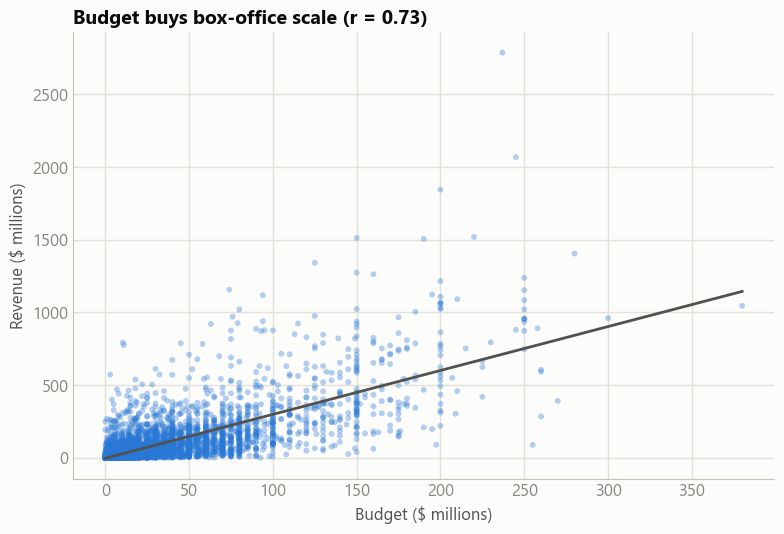

In [2]:
movies = pd.read_parquet(os.path.join(PROC_DIR, "movies_clean.parquet"))
sub = movies.dropna(subset=["budget", "revenue"])
sub = sub[(sub["budget"] > 1000) & (sub["revenue"] > 1000)]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(sub["budget"]/1e6, sub["revenue"]/1e6, s=18, color=BLUE, alpha=0.35,
           edgecolor="none", zorder=3)
z = np.polyfit(sub["budget"]/1e6, sub["revenue"]/1e6, 1)
xs = np.linspace(0, (sub["budget"]/1e6).max(), 50)
ax.plot(xs, np.polyval(z, xs), color=INK_SECONDARY, linewidth=2, zorder=4)
clean_axes(ax)
ax.xaxis.grid(True, color=GRID, linewidth=1); ax.yaxis.grid(True, color=GRID, linewidth=1)
ax.set_xlabel("Budget ($ millions)"); ax.set_ylabel("Revenue ($ millions)")
ax.set_title("Budget buys box-office scale (r = 0.73)", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "01_budget_vs_revenue.png"), dpi=150)
plt.show()

## 2. Genre by median ROI

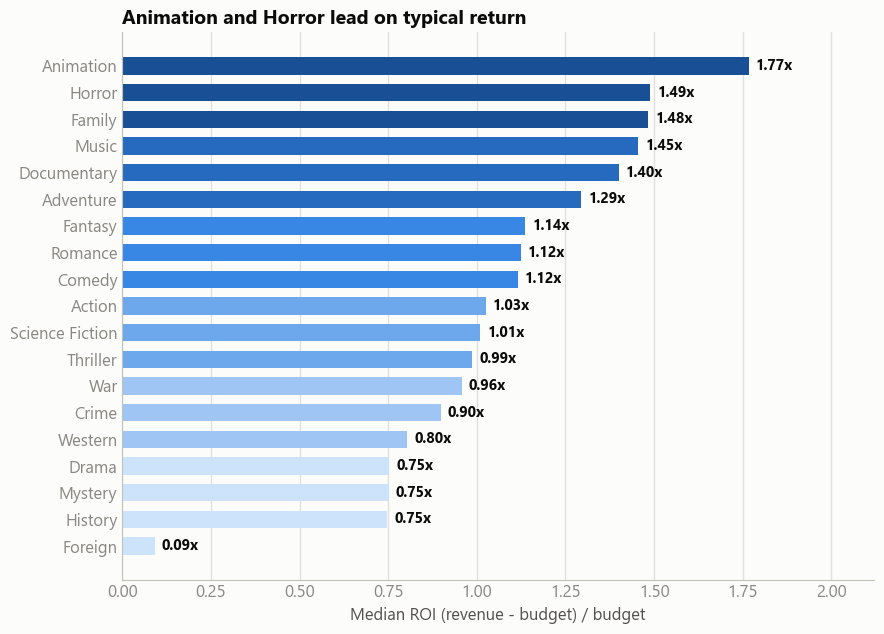

In [3]:
groi = pd.read_csv(os.path.join(SUMMARY_DIR, "genre_roi.csv")).sort_values("median_roi")
fig, ax = plt.subplots(figsize=(9, 6.5))
n = len(groi)
colors = [SEQ6[min(int(i / n * 6), 5)] for i in range(n)]
y = range(n)
ax.barh(y, groi["median_roi"], color=colors, height=0.65)
for i, v in enumerate(groi["median_roi"]):
    ax.text(v + 0.02, i, f"{v:.2f}x", va="center", fontsize=10.5, color=INK_PRIMARY, fontweight="bold")
ax.set_yticks(list(y)); ax.set_yticklabels(groi["genre"])
ax.set_xlim(0, groi["median_roi"].max() * 1.2)
ax.set_xlabel("Median ROI (revenue - budget) / budget")
clean_axes(ax)
ax.xaxis.grid(True, color=GRID, linewidth=1)
ax.set_title("Animation and Horror lead on typical return", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "02_genre_roi.png"), dpi=150)
plt.show()

## 3. Genre by average rating

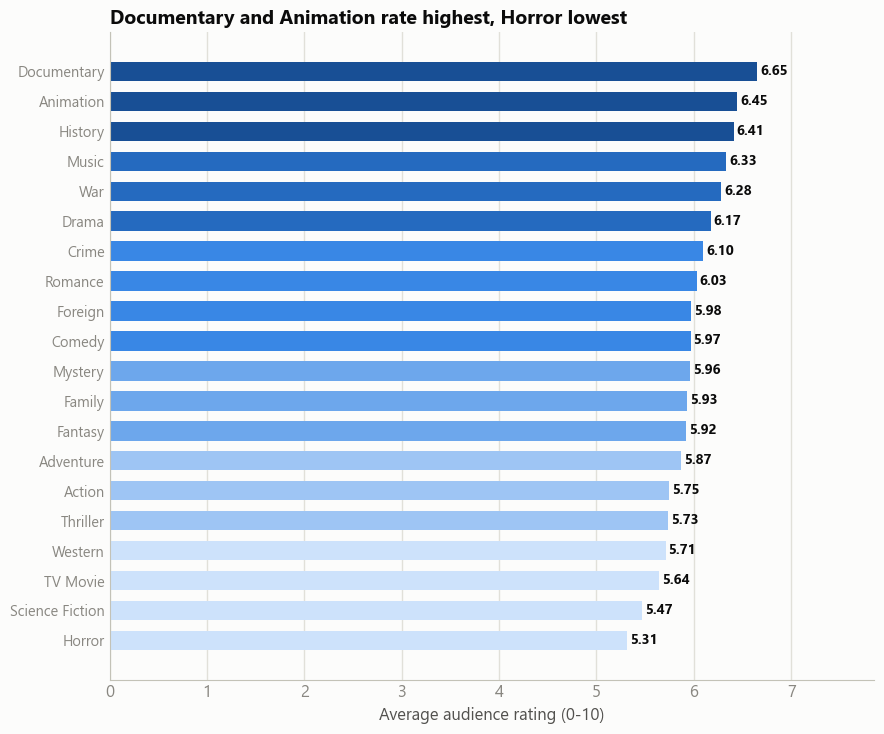

In [4]:
grat = pd.read_csv(os.path.join(SUMMARY_DIR, "genre_rating.csv")).sort_values("avg_vote_average")
fig, ax = plt.subplots(figsize=(9, 7.5))
n = len(grat)
colors = [SEQ6[min(int(i / n * 6), 5)] for i in range(n)]
y = range(n)
ax.barh(y, grat["avg_vote_average"], color=colors, height=0.65)
for i, v in enumerate(grat["avg_vote_average"]):
    ax.text(v + 0.03, i, f"{v:.2f}", va="center", fontsize=10, color=INK_PRIMARY, fontweight="bold")
ax.set_yticks(list(y)); ax.set_yticklabels(grat["genre"], fontsize=10.5)
ax.set_xlim(0, grat["avg_vote_average"].max() * 1.18)
ax.set_xlabel("Average audience rating (0-10)")
clean_axes(ax)
ax.xaxis.grid(True, color=GRID, linewidth=1)
ax.set_title("Documentary and Animation rate highest, Horror lowest", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "03_genre_rating.png"), dpi=150)
plt.show()

## 4. Budget tier vs. rating

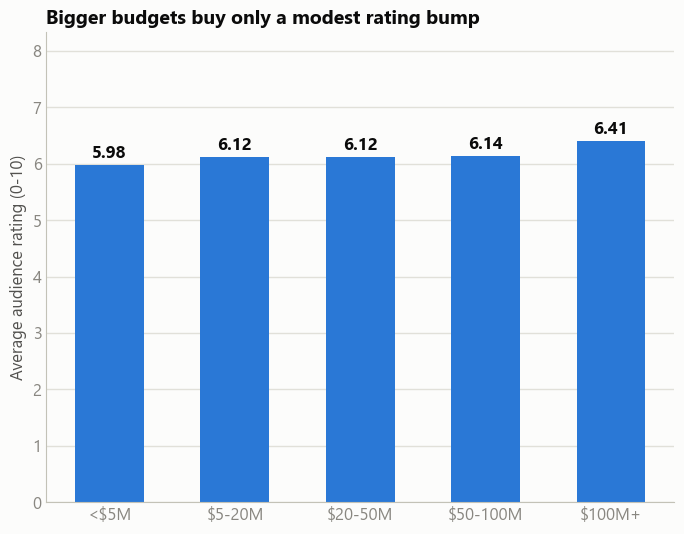

In [5]:
bt = pd.read_csv(os.path.join(SUMMARY_DIR, "budget_tier.csv"))
fig, ax = plt.subplots(figsize=(7, 5.5))
bars = ax.bar(bt["budget_tier"], bt["avg_vote_average"], width=0.55, color=BLUE)
for b, v in zip(bars, bt["avg_vote_average"]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.05, f"{v:.2f}", ha="center", va="bottom",
             fontsize=12.5, color=INK_PRIMARY, fontweight="bold")
clean_axes(ax)
ax.set_ylabel("Average audience rating (0-10)")
ax.set_ylim(0, bt["avg_vote_average"].max() * 1.3)
ax.yaxis.grid(True, color=GRID, linewidth=1)
ax.set_title("Bigger budgets buy only a modest rating bump", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "04_budget_tier_rating.png"), dpi=150)
plt.show()

## 5. Release-month revenue seasonality

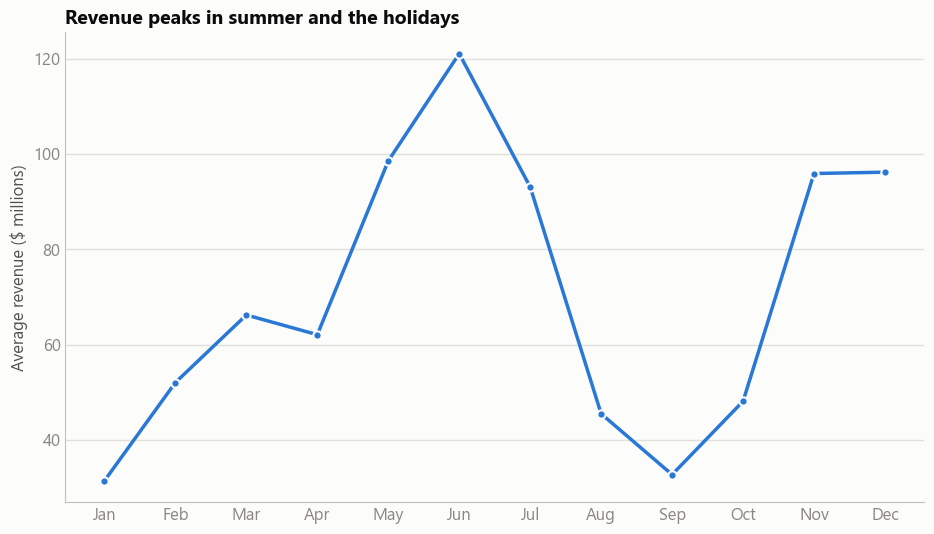

In [6]:
rm = pd.read_csv(os.path.join(SUMMARY_DIR, "release_month.csv"))
MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.plot(range(1,13), rm["avg_revenue"]/1e6, color=BLUE, linewidth=2.5, marker="o", markersize=6,
        markerfacecolor=BLUE, markeredgecolor=SURFACE, markeredgewidth=1.5)
ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTHS)
clean_axes(ax)
ax.yaxis.grid(True, color=GRID, linewidth=1)
ax.set_ylabel("Average revenue ($ millions)")
ax.set_title("Revenue peaks in summer and the holidays", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "05_release_month_revenue.png"), dpi=150)
plt.show()

## Summary

Budget scale, genre, and release timing are all clearly visible levers in this data, while
budget size and audience rating are close to independent — a solid evidence base for a studio's
greenlighting and release-scheduling strategy. See [`docs/05_share.md`](../docs/05_share.md) for
the full write-up.